# 1. 核对三位验证供者

本轮使用此前保留的CID3941、CID3948和CID4461。三位均为未治疗ER+、IDC；参考仍为CID4471、CID4535。四套参考、NNLS特征和参数在预测前固定。

输入由prepare_tcell_validation.py生成，RCTD运行run_tcell_validation.R。下面读取保存的预测，重新计算NNLS与评价指标。


In [1]:
from pathlib import Path
import json
import runpy
import pandas as pd
from IPython.display import display, Image, Markdown
root = Path("/Users/georicl/Documents/sc_sncell_github")
result_dir = root / "results/Wu2021_tcell_validation_v1"
donors = ["CID3941", "CID3948", "CID4461"]
inventory = pd.read_csv(result_dir / "validation_donors.csv")
display(inventory[["donor_id", "histology", "treatment_status", "total_cells", "CAFs", "T cells CD4+", "T cells CD8+"]])
protocol = json.loads((result_dir / "protocol.json").read_text())
print("固定时间：", protocol["frozen_at_utc"])


,donor_id,histology,treatment_status,total_cells,CAFs,T cells CD4+,T cells CD8+
0,CID3941,IDC,Naïve,631,8,108,126
1,CID3948,IDC,Naïve,2327,15,845,498
2,CID4461,IDC,Naïve,631,41,44,11


固定时间： 2026-09-15T05:23:27.436954+00:00


# 2. 查看CD4/CD8配方及CAF背景

每个梯度配方含10个T细胞，CD8为0、2、5、8、10个，其余为CD4，再加入0、1、3个CAF。同一组T细胞及其抽稀计数跨CAF背景配对，每种配方重复5次。

另设5细胞CAF、CD4、CD8纯群，各重复5次。每位供者90个基础混合、两个深度，共180个spot；三位合计540个。同一spot内不重复使用细胞，配方之间允许复用。


In [2]:
designs = pd.concat([pd.read_csv(result_dir / donor / "simulation_design.csv", index_col=0) for donor in donors])
display(designs.groupby(["donor_id", "scenario", "depth_fraction"]).nUMI.agg(["size", "min", "median", "max"]))


size    min   median    max
donor_id scenario depth_fraction                             
CID3941  gradient 0.25              75   3248   5512.0   8648
                  1.00              75  13162  21941.0  34803
         pure     0.25              15   1806   2602.0   4722
                  1.00              15   7356  10459.0  18916
CID3948  gradient 0.25              75   2447   3876.0  10906
                  1.00              75   9889  15191.0  43803
         pure     0.25              15   1171   1667.0   8598
                  1.00              15   4627   6645.0  34372
CID4461  gradient 0.25              75    797   1201.0   2668
                  1.00              75   3147   4694.0  10528
         pure     0.25              15    387    528.0   1321
                  1.00              15   1588   2108.0   5071

# 3. 计算预测误差

主要使用抽稀后实际RNA贡献份额，另存细胞数量份额。CD8缺失的配方单独计算预测均值及权重达到1%、5%的比例；两个阈值在本轮拟合前固定。

每位供者、每个深度及CAF背景分别评价，不合并为一个总体准确率。


In [3]:
evaluation = runpy.run_path(str(root / "src/sc_sncell_github/evaluate_tcell_validation.py"))
evaluation["main"]()


donor_id          variant  n_caf    mae_pp  absent_mean_prediction_pct
 CID3941         baseline      0 20.021144                    7.404857
 CID3941         baseline      1 15.321218                    7.143644
 CID3941         baseline      3  9.434790                    2.220435
 CID3941   donor_balanced      0 29.175033                   37.715420
 CID3941   donor_balanced      1 22.295237                   27.812687
 CID3941   donor_balanced      3 13.157536                    8.461178
 CID3941 epithelial_split      0 20.463281                    8.342575
 CID3941 epithelial_split      1 16.181135                    8.036578
 CID3941 epithelial_split      3 10.195190                    2.444952
 CID3941   balanced_split      0 30.251794                   43.398810
 CID3941   balanced_split      1 25.120438                   38.871171
 CID3941   balanced_split      3 16.142926                   17.212804
 CID3948         baseline      0 24.288921                   32.151241
 CID39

# 4. 查看CD8梯度和缺失配方

散点表示各模拟spot，连线连接同一CD8细胞数量下的平均RNA份额与平均预测。虚线表示预测等于真实份额。热图展示CD8不存在时的平均预测权重。


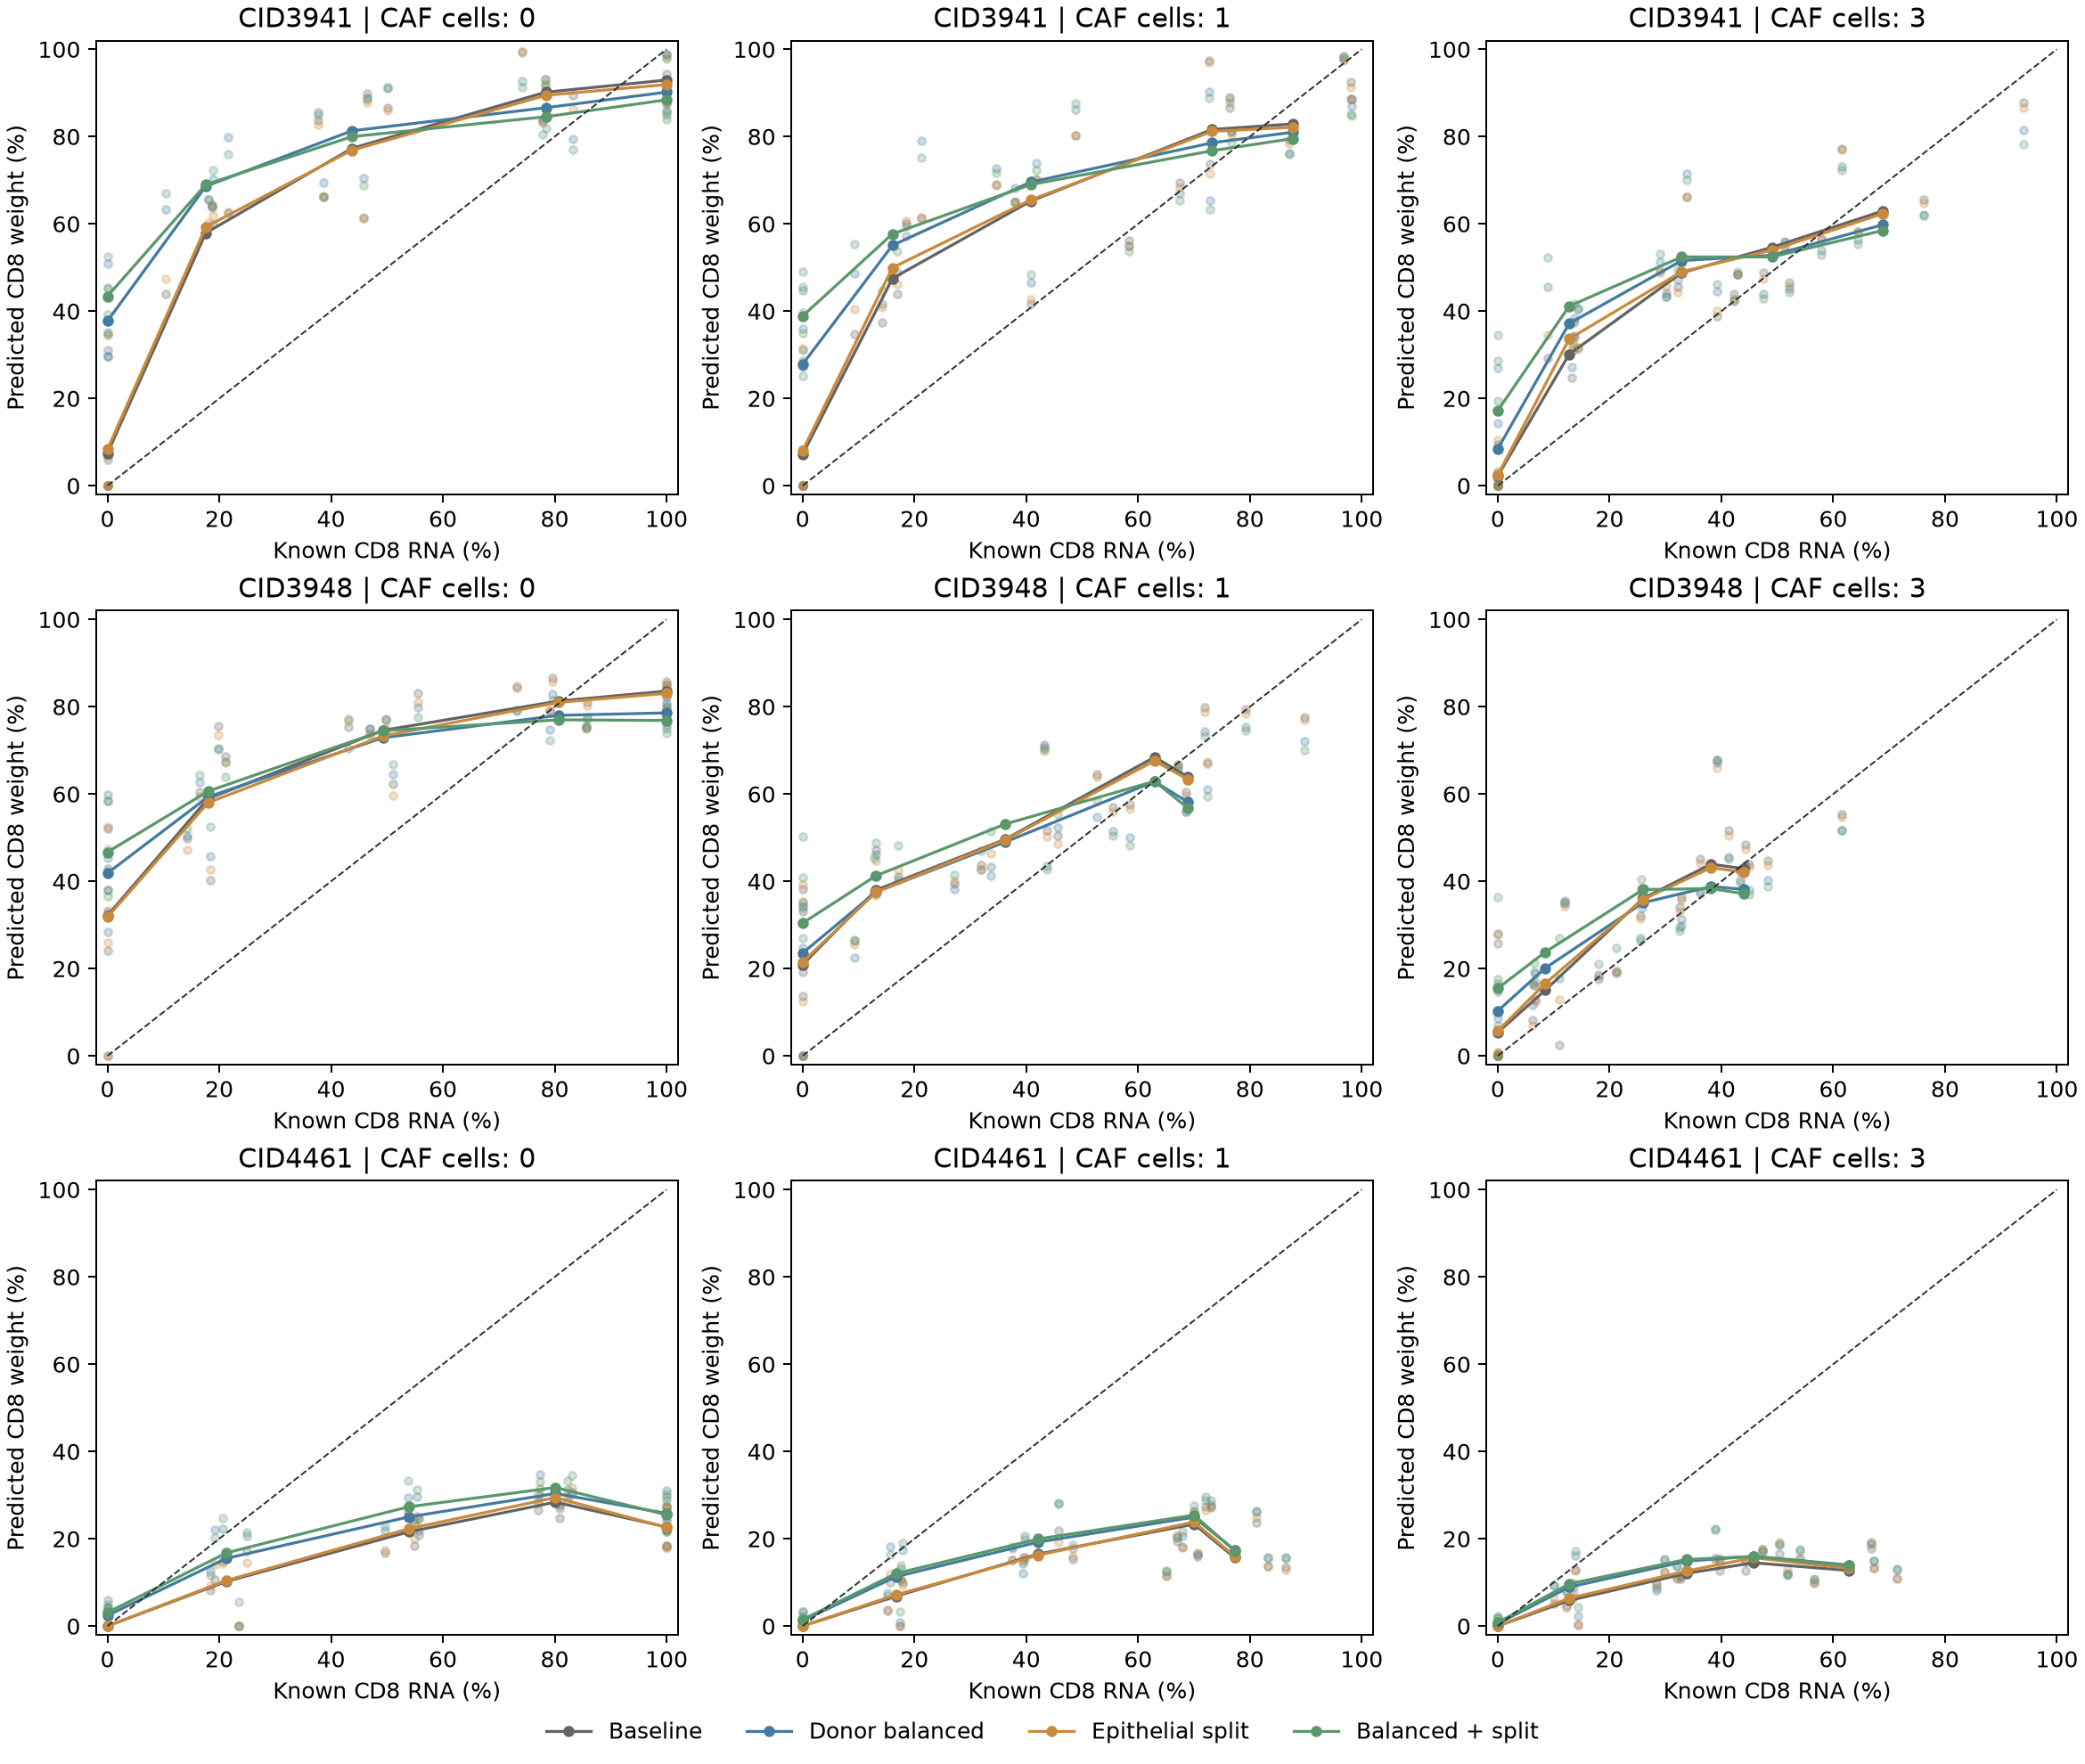

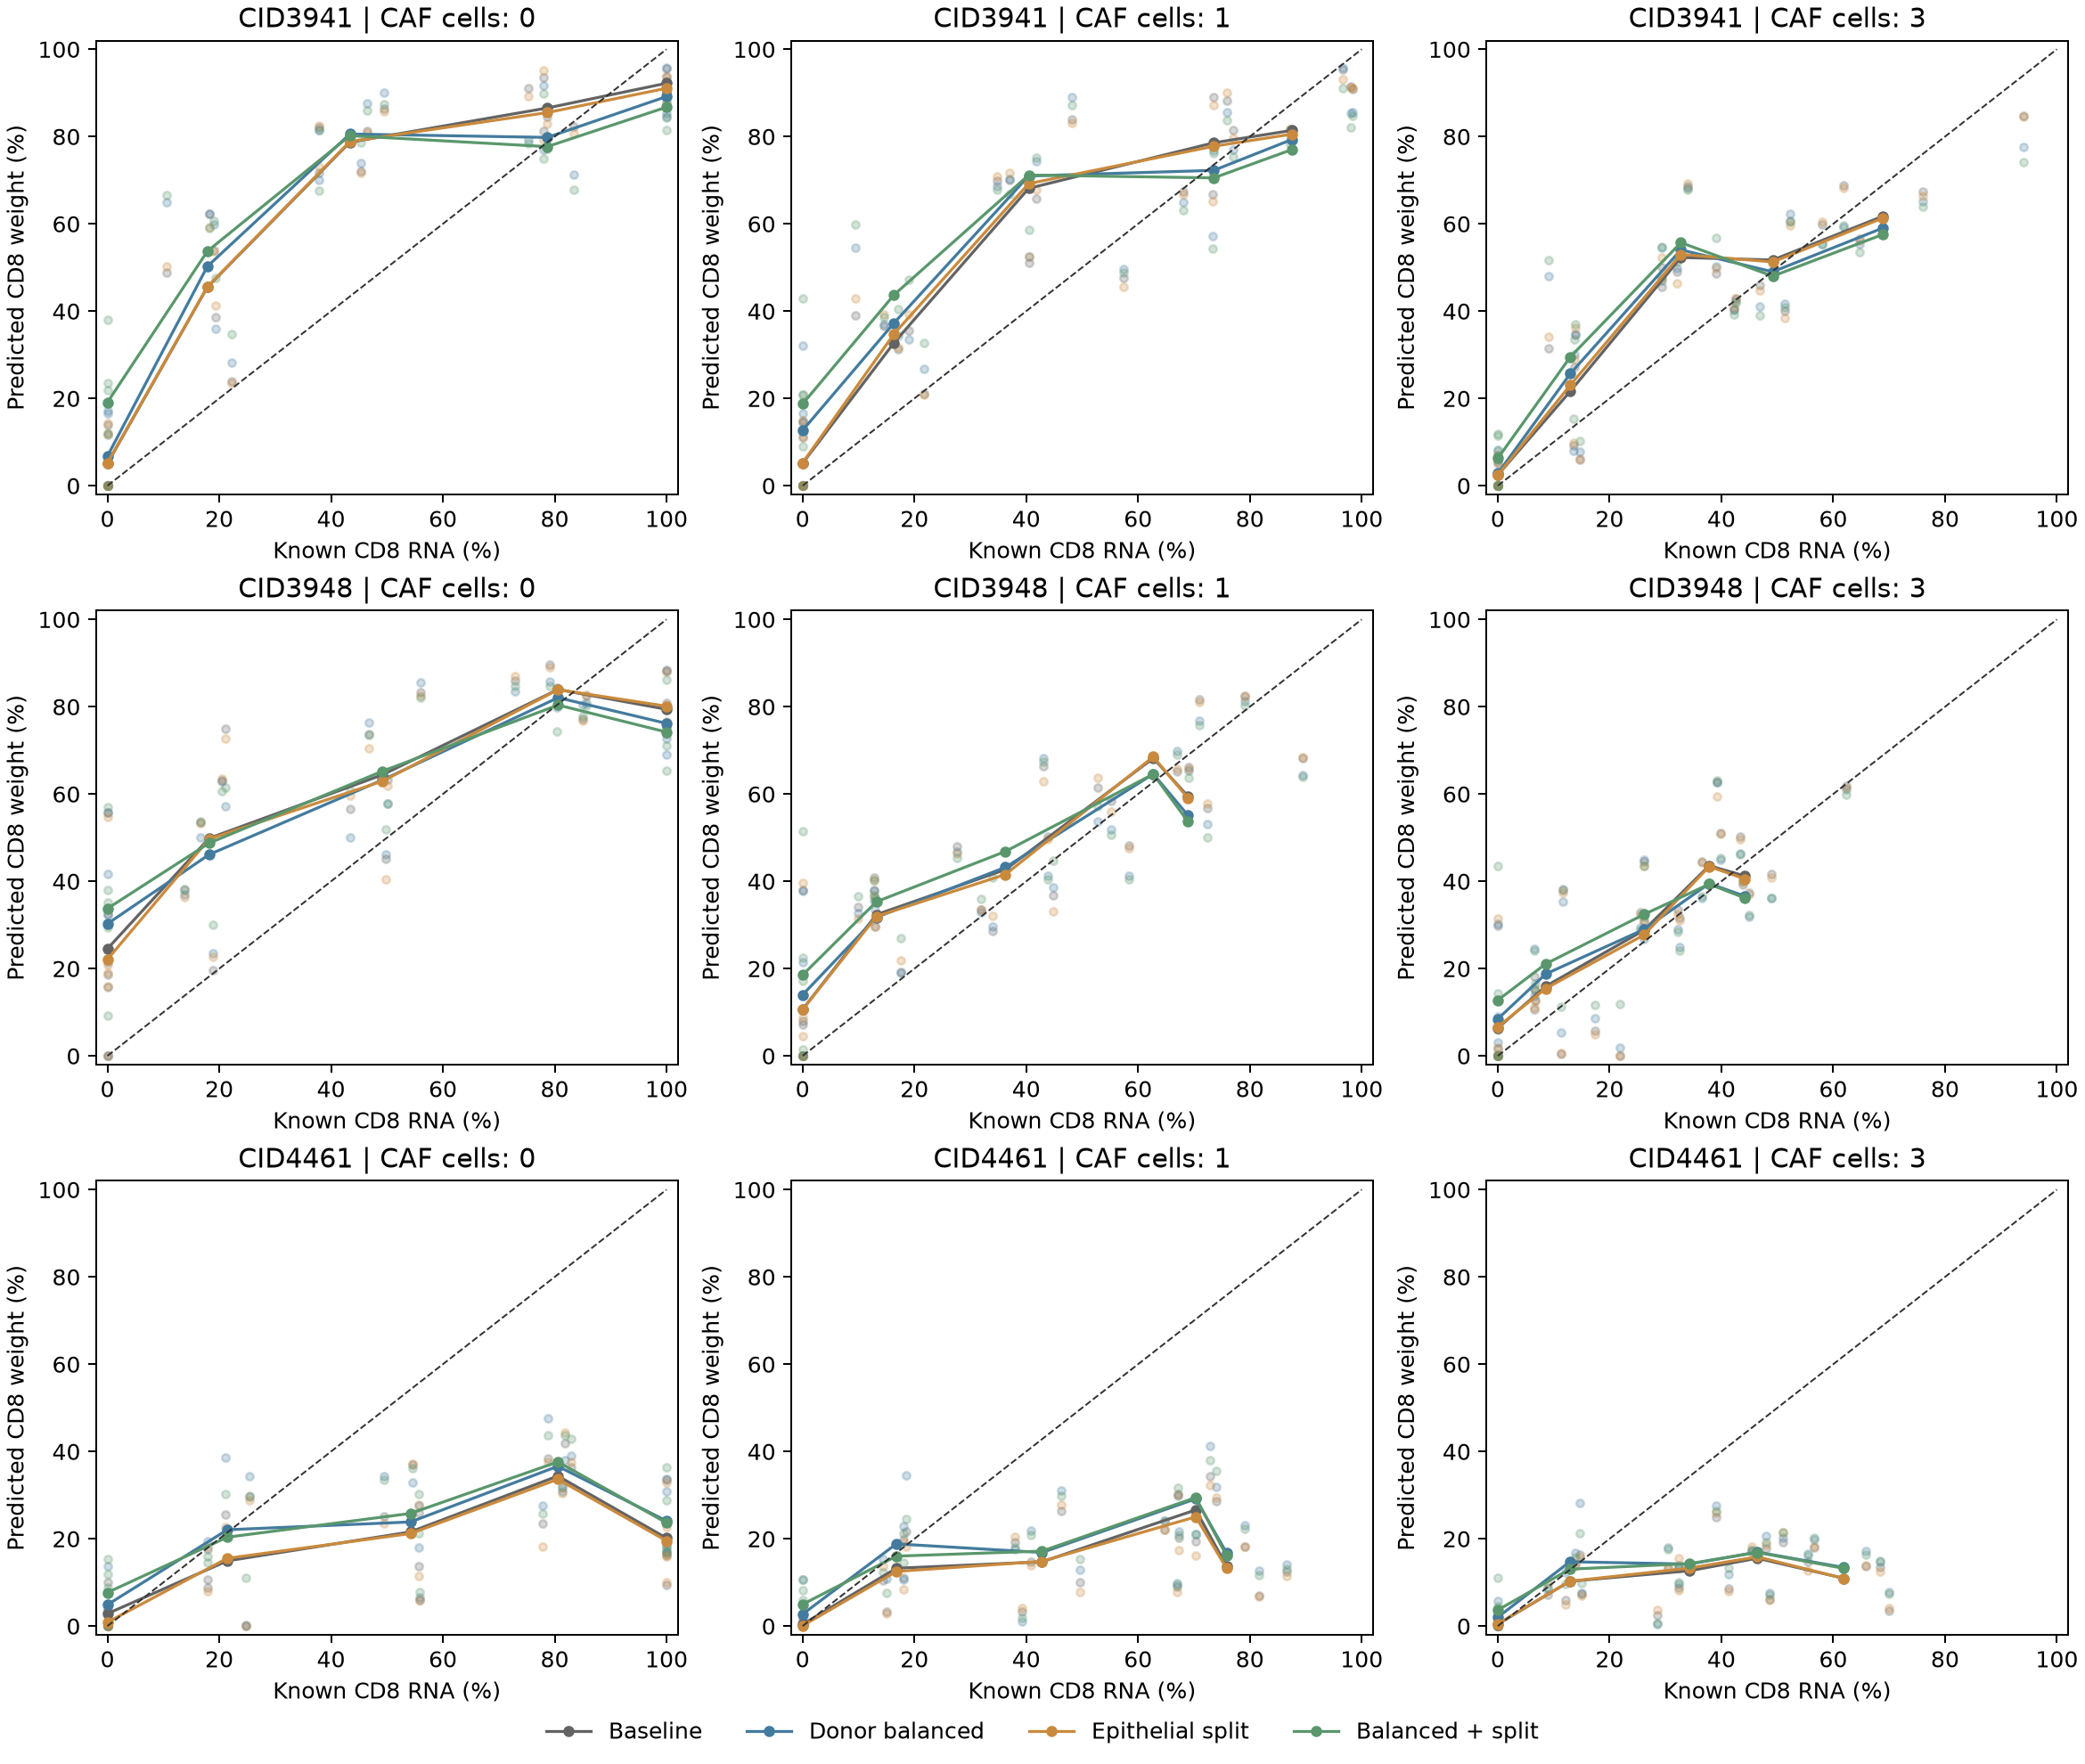

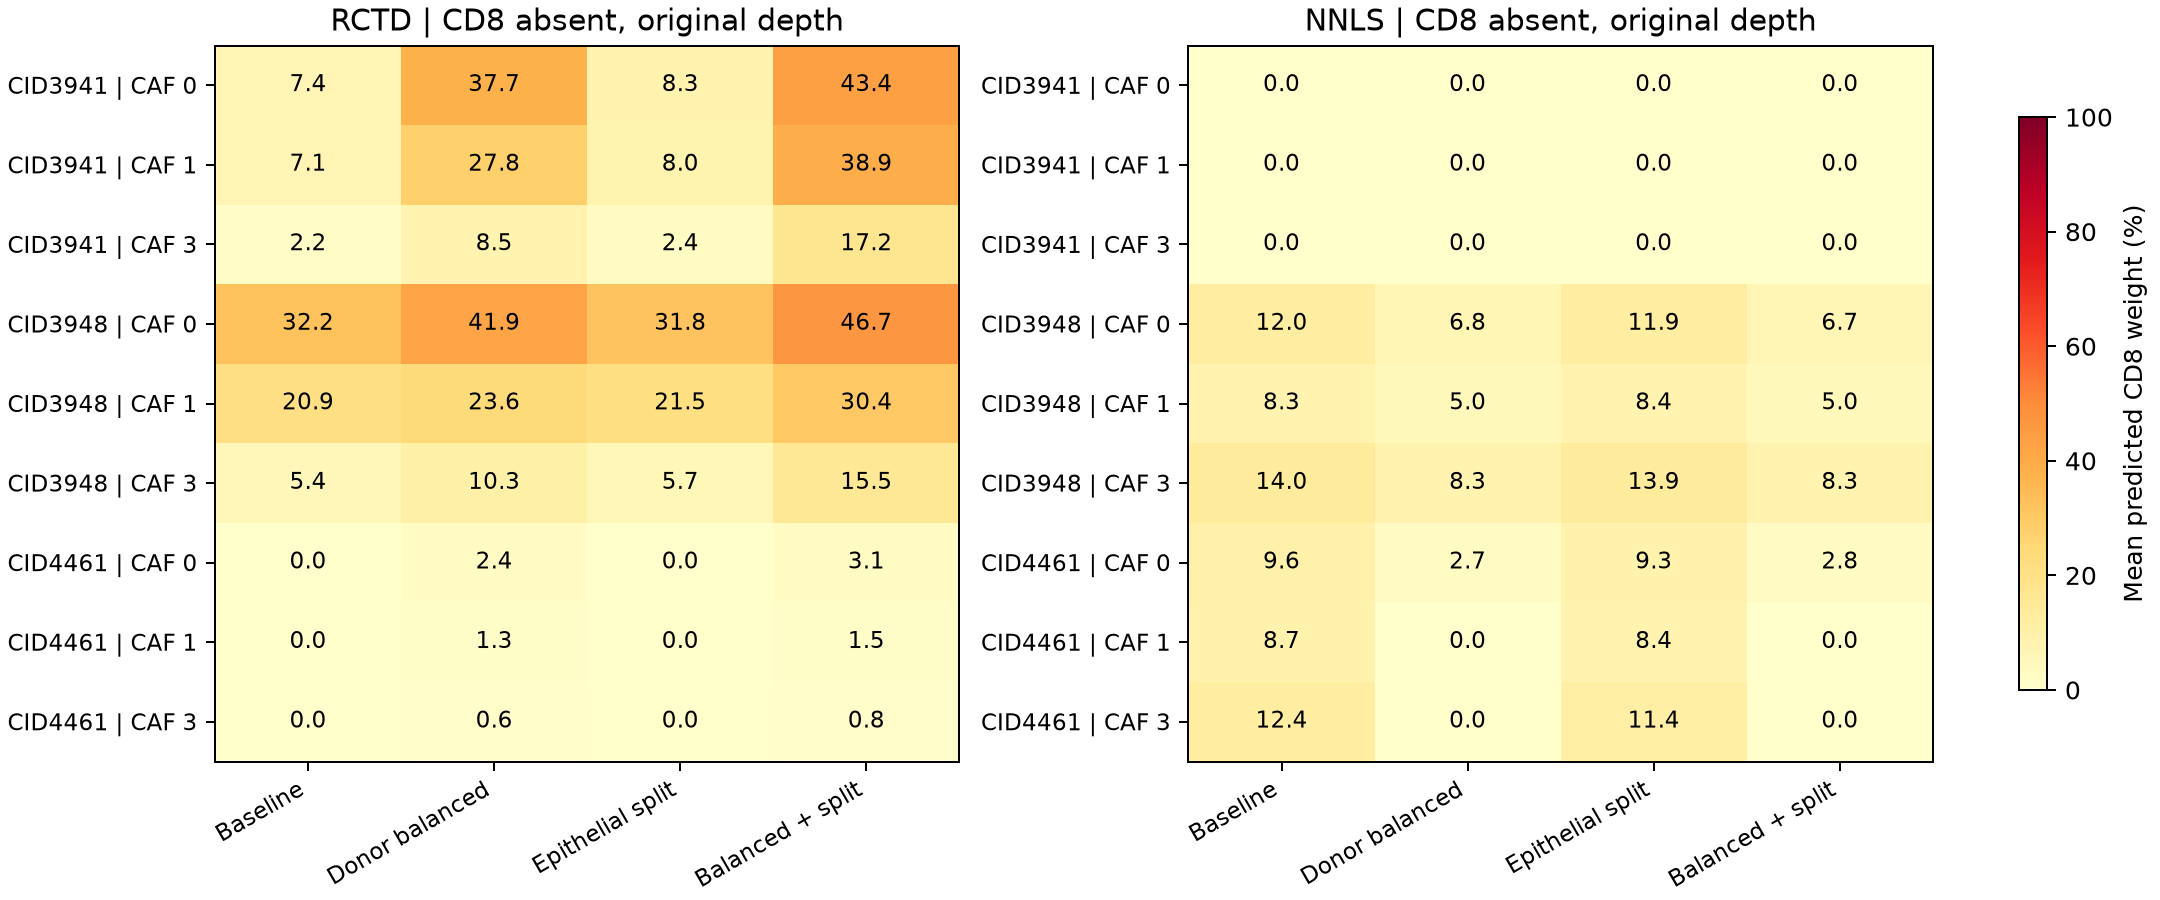

In [4]:
display(Image(filename=str(result_dir / "rctd_cd8_gradient_depth100.png")))
display(Image(filename=str(result_dir / "rctd_cd8_gradient_depth25.png")))
display(Image(filename=str(result_dir / "cd8_zero_predictions.png")))


# 5. 查看纯群和CAF配对变化

加入CAF会稀释真实CD8 RNA份额，因此配对比较使用误差变化，不直接把预测权重下降解释成混淆。绝对误差变化大于零，表示加入CAF后误差增大。


In [5]:
pure = pd.read_csv(result_dir / "pure_control_summary.csv")
display(pure[pure.method.eq("RCTD") & pure.depth_fraction.eq(1)])
paired = pd.read_csv(result_dir / "paired_caf_effect_summary.csv")
display(paired[paired.method.eq("RCTD") & paired.depth_fraction.eq(1) & paired.cell_type.eq("T cells CD8+")])
display(pd.read_csv(result_dir / "source_mixture_diversity.csv").groupby("donor_id")[["n_spots", "distinct_source_sets"]].sum())


,donor_id,variant,method,depth_fraction,cell_type,n_spots,dominant_matches,mean_weight_on_true_type,mean_cd4_weight,mean_cd8_weight
0,CID3941,baseline,RCTD,1.0,CAFs,5,1,0.307215,0.000019,0.000019
1,CID3941,baseline,RCTD,1.0,T cells CD4+,5,5,0.764538,0.764538,0.171907
2,CID3941,baseline,RCTD,1.0,T cells CD8+,5,5,0.903831,0.020745,0.903831
12,CID3941,donor_balanced,RCTD,1.0,CAFs,5,1,0.399003,0.000018,0.000018
13,CID3941,donor_balanced,RCTD,1.0,T cells CD4+,5,3,0.506393,0.506393,0.341322
14,CID3941,donor_balanced,RCTD,1.0,T cells CD8+,5,5,0.878140,0.019089,0.878140
24,CID3941,epithelial_split,RCTD,1.0,CAFs,5,1,0.305572,0.000016,0.000016
25,CID3941,epithelial_split,RCTD,1.0,T cells CD4+,5,5,0.741673,0.741673,0.185478
26,CID3941,epithelial_split,RCTD,1.0,T cells CD8+,5,5,0.892379,0.023047,0.892379
36,CID3941,balanced_split,RCTD,1.0,CAFs,5,1,0.398929,0.000016,0.000016


,donor_id,variant,method,depth_fraction,n_caf,cell_type,error_change_pp,absolute_error_change_pp
20,CID3941,balanced_split,RCTD,1.0,1,T cells CD8+,-4.305491,-5.131356
23,CID3941,balanced_split,RCTD,1.0,3,T cells CD8+,-13.512125,-14.108868
44,CID3941,baseline,RCTD,1.0,1,T cells CD8+,-3.882139,-4.699926
47,CID3941,baseline,RCTD,1.0,3,T cells CD8+,-10.178051,-10.586354
68,CID3941,donor_balanced,RCTD,1.0,1,T cells CD8+,-6.090655,-6.879796
71,CID3941,donor_balanced,RCTD,1.0,3,T cells CD8+,-15.707826,-16.017497
92,CID3941,epithelial_split,RCTD,1.0,1,T cells CD8+,-3.429980,-4.282146
95,CID3941,epithelial_split,RCTD,1.0,3,T cells CD8+,-9.666468,-10.268090
116,CID3948,balanced_split,RCTD,1.0,1,T cells CD8+,-4.902535,-10.777190
119,CID3948,balanced_split,RCTD,1.0,3,T cells CD8+,-10.291654,-18.523035


,n_spots,distinct_source_sets
donor_id,,
CID3941,180,178
CID3948,180,180
CID4461,180,178


# 6. 核对来源和评价计算

重建全部270个原深度混合，核对来源标签、参考隔离及输入哈希，再复算误差、缺失类型指标、纯群匹配和CAF配对变化。


In [6]:
runpy.run_path(str(root / "src/sc_sncell_github/validate_tcell_validation.py"))
checks = json.loads((result_dir / "validation_checks.json").read_text())
print("通过检查：", sum(checks["checks"].values()), "/", len(checks["checks"]))


Checks: 140 / 140 max recalculation difference: 7.105427357601002e-15
通过检查： 140 / 140


# 7. 阅读本轮结果


In [7]:
display(Markdown((result_dir / "interpretation.md").read_text()))


# 三位供者的CD4/CD8与CAF背景验证

## 1. 固定设计

CID3941、CID3948、CID4461均为未治疗ER+、IDC，临床补充表1分别对应第8、10、18行。三位供者此前保留为验证候选，本轮未加入参考。
每个梯度spot含10个T细胞，CD8个数为0、2、5、8、10，其余为CD4；分别加入0、1、3个CAF。每种配方重复5次，另为CAF、CD4和CD8各生成5个五细胞纯群。
每位供者90个基础混合，在原深度和25%深度各生成一个版本，共180个spot；三位合计540个。相同T细胞及其抽稀计数跨CAF背景配对，CAF 1使用CAF 3中的第一个细胞。
CID3941只有8个CAF，CID4461只有11个CD8，配方之间会复用来源细胞。不同来源细胞组合数保存在source_mixture_diversity.csv。
四套参考、NNLS特征和RCTD参数均在预测前固定；RCTD按供者分别进行平台校正和拟合。本轮是T细胞与CAF组成的针对性模拟，不混入其他细胞类型。

## 2. RCTD原深度CD8预测

每行MAE来自25个梯度spot；CD8实际缺失的配方为其中5个。MAE单位为百分点，缺失预测均值单位为百分比。

| 供者 | 参考 | CAF个数 | CD8 MAE | CD8缺失时均值 | 缺失时≥1% | 缺失时≥5% |
|---|---|---:|---:|---:|---:|---:|
| CID3941 | 原参考 | 0 | 20.02 | 7.40 | 40% | 40% |
| CID3941 | 原参考 | 1 | 15.32 | 7.14 | 40% | 40% |
| CID3941 | 原参考 | 3 | 9.43 | 2.22 | 40% | 20% |
| CID3941 | 供者均衡 | 0 | 29.18 | 37.72 | 100% | 100% |
| CID3941 | 供者均衡 | 1 | 22.30 | 27.81 | 80% | 80% |
| CID3941 | 供者均衡 | 3 | 13.16 | 8.46 | 40% | 40% |
| CID3941 | 上皮拆分 | 0 | 20.46 | 8.34 | 40% | 40% |
| CID3941 | 上皮拆分 | 1 | 16.18 | 8.04 | 40% | 40% |
| CID3941 | 上皮拆分 | 3 | 10.20 | 2.44 | 40% | 20% |
| CID3941 | 均衡并拆分 | 0 | 30.25 | 43.40 | 100% | 100% |
| CID3941 | 均衡并拆分 | 1 | 25.12 | 38.87 | 100% | 100% |
| CID3941 | 均衡并拆分 | 3 | 16.14 | 17.21 | 80% | 60% |
| CID3948 | 原参考 | 0 | 24.29 | 32.15 | 80% | 80% |
| CID3948 | 原参考 | 1 | 14.09 | 20.88 | 80% | 80% |
| CID3948 | 原参考 | 3 | 7.18 | 5.38 | 20% | 20% |
| CID3948 | 供者均衡 | 0 | 26.91 | 41.85 | 100% | 100% |
| CID3948 | 供者均衡 | 1 | 14.70 | 23.55 | 80% | 80% |
| CID3948 | 供者均衡 | 3 | 7.97 | 10.31 | 60% | 60% |
| CID3948 | 上皮拆分 | 0 | 23.91 | 31.81 | 80% | 80% |
| CID3948 | 上皮拆分 | 1 | 14.03 | 21.48 | 80% | 80% |
| CID3948 | 上皮拆分 | 3 | 6.66 | 5.73 | 20% | 20% |
| CID3948 | 均衡并拆分 | 0 | 28.88 | 46.68 | 100% | 100% |
| CID3948 | 均衡并拆分 | 1 | 18.11 | 30.42 | 80% | 80% |
| CID3948 | 均衡并拆分 | 3 | 10.36 | 15.48 | 80% | 80% |
| CID4461 | 原参考 | 0 | 34.48 | 0.01 | 0% | 0% |
| CID4461 | 原参考 | 1 | 28.75 | 0.01 | 0% | 0% |
| CID4461 | 原参考 | 3 | 21.97 | 0.01 | 0% | 0% |
| CID4461 | 供者均衡 | 0 | 32.57 | 2.41 | 60% | 20% |
| CID4461 | 供者均衡 | 1 | 27.10 | 1.26 | 60% | 0% |
| CID4461 | 供者均衡 | 3 | 20.55 | 0.59 | 20% | 0% |
| CID4461 | 上皮拆分 | 0 | 34.10 | 0.01 | 0% | 0% |
| CID4461 | 上皮拆分 | 1 | 28.58 | 0.01 | 0% | 0% |
| CID4461 | 上皮拆分 | 3 | 21.44 | 0.01 | 0% | 0% |
| CID4461 | 均衡并拆分 | 0 | 31.84 | 3.10 | 80% | 20% |
| CID4461 | 均衡并拆分 | 1 | 26.74 | 1.48 | 60% | 0% |
| CID4461 | 均衡并拆分 | 3 | 20.50 | 0.83 | 40% | 0% |

## 3. 本轮观察

原深度、没有CAF的梯度中，原参考RCTD的CD8 MAE在CID3941、CID3948和CID4461分别为20.02、24.29和34.48个百分点。单独上皮拆分分别为20.46、23.91和34.10，没有消除T细胞定量误差。
CD8实际为零时，CID3941的原参考平均预测为7.40%，供者均衡为37.72%，组合方案为43.40%；CID3948分别为32.15%、41.85%和46.68%。这些数值来自10个CD4、没有CAF的配方，每组5个spot。
CID4461的零CD8预测较低，但真实CD8存在时严重低估。原参考五细胞纯CD8对照中，正确类型平均权重为20.3%，主导类型匹配2/5；另外三套参考也只有2/5匹配。低假阳性不能替代对真实CD8的识别。
已知组成沿用作者细胞标签。CID4461的11个CD8细胞UMI中位数为400，CID3941和CID3948分别为1641和1160；CID4461的低估可能同时受来源细胞表达信息较少和参考覆盖影响，本轮没有把两者分开。
相同CD4细胞、CD8始终为零，CAF从0个增加到3个时，CID3948原参考的预测CD8从32.15%降到5.38%，CID3941从7.40%降到2.22%。模型在这些零CD8配方中也能产生CAF增加、预测CD8下降的表象。因此真实切片上的权重负相关本身不足以说明CAF与CD8发生空间排斥。
25%深度下，没有CAF的原参考CD8 MAE分别为16.83、20.31和34.29个百分点，误差仍然存在。3个CAF背景下，各供者及方案的RCTD CAF MAE为6.47至16.89个百分点，CAF定量也随供者和配方变化。
NNLS原参考在没有CAF的原深度梯度中，三位供者CD8 MAE分别为14.14、16.81和49.40个百分点；它在前两位低于RCTD，在CID4461更差，不能据此直接替换为统一方法。
此前CID4463的癌上皮背景配方中，CD8真实RNA份额均值只有2.83%，中位数1.20%；本轮覆盖0%至100%的T细胞RNA组成。此前较小的绝对误差不能直接推广到完整比例范围，也不能推广到其他供者。
本轮没有一套参考解决了三个供者的CD8识别。原参考和上皮拆分仍可作为后续诊断对照；供者均衡及组合方案不能仅凭之前的上皮改善就用于正式CAF/CD8关系推断。

## 4. 纯CD4和纯CD8对照

下表为原深度五细胞纯群，每类5个。主导匹配只检查权重最高的标签，同时列出纯CD4中错误分配给CD8的平均权重。

| 供者 | 方法 | 参考 | 纯CD4主导匹配 | 纯CD4的CD8权重 | 纯CD8主导匹配 | 纯CD8正确权重 |
|---|---|---|---:|---:|---:|---:|
| CID3941 | RCTD | 原参考 | 5/5 | 17.2% | 5/5 | 90.4% |
| CID3941 | RCTD | 供者均衡 | 3/5 | 34.1% | 5/5 | 87.8% |
| CID3941 | RCTD | 上皮拆分 | 5/5 | 18.5% | 5/5 | 89.2% |
| CID3941 | RCTD | 均衡并拆分 | 2/5 | 42.6% | 5/5 | 87.2% |
| CID3941 | NNLS | 原参考 | 5/5 | 0.0% | 5/5 | 82.0% |
| CID3941 | NNLS | 供者均衡 | 5/5 | 0.0% | 5/5 | 70.5% |
| CID3941 | NNLS | 上皮拆分 | 5/5 | 0.0% | 5/5 | 81.7% |
| CID3941 | NNLS | 均衡并拆分 | 5/5 | 0.0% | 5/5 | 69.3% |
| CID3948 | RCTD | 原参考 | 5/5 | 11.2% | 5/5 | 86.2% |
| CID3948 | RCTD | 供者均衡 | 5/5 | 18.1% | 5/5 | 86.1% |
| CID3948 | RCTD | 上皮拆分 | 5/5 | 11.4% | 5/5 | 85.7% |
| CID3948 | RCTD | 均衡并拆分 | 3/5 | 30.5% | 5/5 | 84.8% |
| CID3948 | NNLS | 原参考 | 5/5 | 4.9% | 5/5 | 71.9% |
| CID3948 | NNLS | 供者均衡 | 5/5 | 3.0% | 5/5 | 56.2% |
| CID3948 | NNLS | 上皮拆分 | 5/5 | 4.9% | 5/5 | 71.9% |
| CID3948 | NNLS | 均衡并拆分 | 5/5 | 3.0% | 5/5 | 56.2% |
| CID4461 | RCTD | 原参考 | 4/5 | 0.7% | 2/5 | 20.3% |
| CID4461 | RCTD | 供者均衡 | 4/5 | 2.4% | 2/5 | 23.5% |
| CID4461 | RCTD | 上皮拆分 | 4/5 | 0.6% | 2/5 | 20.2% |
| CID4461 | RCTD | 均衡并拆分 | 4/5 | 4.8% | 2/5 | 23.7% |
| CID4461 | NNLS | 原参考 | 0/5 | 6.1% | 0/5 | 0.0% |
| CID4461 | NNLS | 供者均衡 | 0/5 | 0.0% | 0/5 | 4.3% |
| CID4461 | NNLS | 上皮拆分 | 0/5 | 5.9% | 0/5 | 0.0% |
| CID4461 | NNLS | 均衡并拆分 | 0/5 | 0.0% | 0/5 | 0.0% |

## 5. 配对变化与完整文件

加入CAF会改变真实CD8 RNA份额。配对评价使用“预测减真实”的误差变化，以及绝对误差变化，避免把正常的RNA稀释当作错误。正的绝对误差变化表示加入CAF后误差增大。
gradient_metrics.csv包含全部13类、两种真值和两个深度；cd8_key_metrics.csv汇总CD8；paired_caf_effects.csv保存逐配对变化；pure_control_summary.csv保存纯群表现。
本轮未根据验证结果修改参考或参数，也没有把540个模拟spot当作540位独立供者。
